In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.6 MB/s eta 0:00:00


### Import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização
from scipy.stats import kstest, norm
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# Modelling
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Fine Tunning
from skopt import BayesSearchCV


# Previsão de Consumo de Energia Residencial (Regressão)

Descrição do Problema

Objetivo: Uma empresa de energia deseja prever o consumo mensal de energia elétrica de residências com base em características dos imóveis e do comportamento dos moradores. O objetivo é construir um modelo que auxilie na estimativa de consumo e identificação de padrões para otimização de recursos.

Características (features):

- IdResidencia: Identificador único da residência.
- TamanhoResidencia: Área da residência em metros quadrados.
- NumeroMoradores: Número de moradores na residência.
- NumeroAparelhos: Quantidade de aparelhos elétricos na residência.
- UsoArCondicionado: Indica se a residência usa ar-condicionado frequentemente (0 = Não, 1 = Sim).
- RendaFamiliar: Renda familiar mensal em reais.
- ConsumoEnergia: Consumo mensal de energia elétrica em kWh (variável alvo).



### Dataset



In [3]:
# Definindo parâmetros do dataset
np.random.seed(42)  # Para resultados reproduzíveis
n_samples = 1000  # Número de amostras no dataset

# Gerando os dados
tamanho_residencia = np.random.uniform(50, 400, size=n_samples).round(2)
numero_moradores = np.random.randint(1, 7, size=n_samples)
numero_aparelhos = np.random.randint(5, 30, size=n_samples)
uso_ar_condicionado = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
renda_familiar = np.random.uniform(2000, 20000, size=n_samples).round(2)

# Regras para determinar o consumo de energia (introduzindo variabilidade)
consumo_energia = (
    0.8 * tamanho_residencia +
    50 * numero_moradores +
    20 * numero_aparelhos +
    200 * uso_ar_condicionado +
    np.random.normal(0, 50, size=n_samples)  # Ruído aleatório
).round(2)

# Criando o DataFrame
dados = pd.DataFrame({
    "IdResidencia": range(1, n_samples + 1),
    "TamanhoResidencia": tamanho_residencia,
    "NumeroMoradores": numero_moradores,
    "NumeroAparelhos": numero_aparelhos,
    "UsoArCondicionado": uso_ar_condicionado,
    "RendaFamiliar": renda_familiar,
    "ConsumoEnergia": consumo_energia,
})

# Salvando o dataset em um arquivo CSV
dados.to_csv("dataset_consumo_energia.csv", index=False)

print("Dataset gerado e salvo como 'dataset_consumo_energia.csv'")


Dataset gerado e salvo como 'dataset_consumo_energia.csv'


In [4]:
dados.sample(10)

,IdResidencia,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia
719,720,305.80,6,13,1,6139.89,986.01
735,736,357.02,5,9,0,19791.58,715.73
736,737,187.36,3,29,0,19591.04,933.41
294,295,94.47,4,11,0,10813.24,522.24
205,206,53.22,5,12,0,13207.35,496.62
589,590,103.17,6,8,1,9257.79,638.43
668,669,115.30,5,22,1,12590.34,932.66
365,366,185.14,2,13,0,9887.22,507.56
600,601,109.13,3,13,0,9763.43,393.41
794,795,56.34,5,12,0,7975.49,554.86


# Business Problem

Prever o consumo mensal de energia por residência

# Business Understading

```
Qual a motivação? Responder a pergunta "Qual o consumo mensal de cada residência baseado em suas características?"

Qual a causa raiz? Suas características como o numero de pessoas, aparelhos, tamanho da casa, entre outros.

Qual é o Dono do Projeto? Empresa de energia

Qual o Formato da Solução?

* Granularidade: Mês
* Tipo de problema: Previsão de consumo mensal
* Potenciais Métodos: Regressão
```

# Data Extraction

In [5]:
df_raw = dados.copy()

## Data Cleaning


Esta etapa visa entender os desafios do problema. Quantidade de dados, tipos de dos dados (numéricos, categoricos, temporais, etc),
Quantidade de dados faltantes (NaN) e a realização da estatística descritiva (média, mediana, variancia, etc).


## Rename columns

In [6]:
df_raw

,IdResidencia,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia
0,1,181.09,4,27,1,9802.50,1110.15
1,2,382.75,6,8,0,19949.28,840.66
2,3,306.20,3,22,0,12063.07,948.53
3,4,259.53,5,27,0,7780.92,977.40
4,5,104.61,1,10,1,5962.00,558.26
...,...,...,...,...,...,...,...
995,996,82.05,1,12,0,7333.86,396.64
996,997,371.06,3,15,0,4582.45,763.07
997,998,97.89,3,24,0,4726.02,681.68
998,999,382.58,4,5,0,9789.89,648.05


## Data Dimension

In [7]:
# Dimensão
print('Linhas...: ' + str(df_raw.shape[0]))
print('Colunas..: ' + str(df_raw.shape[1]))

Linhas...: 1000
Colunas..: 7


## Data type

In [8]:
df_raw

,IdResidencia,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia
0,1,181.09,4,27,1,9802.50,1110.15
1,2,382.75,6,8,0,19949.28,840.66
2,3,306.20,3,22,0,12063.07,948.53
3,4,259.53,5,27,0,7780.92,977.40
4,5,104.61,1,10,1,5962.00,558.26
...,...,...,...,...,...,...,...
995,996,82.05,1,12,0,7333.86,396.64
996,997,371.06,3,15,0,4582.45,763.07
997,998,97.89,3,24,0,4726.02,681.68
998,999,382.58,4,5,0,9789.89,648.05


In [9]:
df_raw.dtypes

,0
IdResidencia,int64
TamanhoResidencia,float64
NumeroMoradores,int64
NumeroAparelhos,int64
UsoArCondicionado,int64
RendaFamiliar,float64
ConsumoEnergia,float64


## Check NA

In [10]:
df_raw.isna().sum()

,0
IdResidencia,0
TamanhoResidencia,0
NumeroMoradores,0
NumeroAparelhos,0
UsoArCondicionado,0
RendaFamiliar,0
ConsumoEnergia,0


# 1. Análise Exploratória dos Dados

```
Analisar a distribuição das variáveis identificando possíveis outliers e entendendo como cada variável pode influenciar a decisão de compra.
```



In [11]:
df_1 = df_raw.copy()

## Descriptive Statistical

```
Conjunto de técnicas matemáticas para resumir e descrever dados.
Foca em medidas numéricas e tabelas:
```
* Média, mediana, moda
* Variância, desvio-padrão
* Quartis, percentis
* Tabelas de frequência
* Histogramas e boxplots (quando acompanhada de gráficos simples)
```
O objetivo é resumir os dados de forma objetiva.

```

In [12]:
num_attributes = df_1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df_1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

In [13]:
# Numerical Attributes
# Central Tendency - Mean, Median
ct_1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct_2 = pd.DataFrame(num_attributes.apply(np.median)).T
# Dispesion - std, min, max, range, skew, kurtosis
d_1 = pd.DataFrame(num_attributes.apply(np.std)).T
d_2 = pd.DataFrame(num_attributes.apply(min)).T
d_3 = pd.DataFrame(num_attributes.apply(max)).T
d_4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d_5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d_6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T
# Concatenate
metrics = pd.concat([d_2, d_3, d_4, ct_1, ct_2, d_1, d_5, d_6]).T.reset_index()
metrics.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
metrics


,attributes,min,max,range,mean,median,std,skew,kurtosis
0,IdResidencia,1.00,1000.00,999.00,500.50000,500.500,288.674990,0.000000,-1.200000
1,TamanhoResidencia,51.62,399.90,348.28,221.58981,223.885,102.196921,0.038846,-1.229250
2,NumeroMoradores,1.00,6.00,5.00,3.49800,4.000,1.711723,-0.009769,-1.290227
3,NumeroAparelhos,5.00,29.00,24.00,17.30000,18.000,7.320656,-0.057196,-1.266388
4,UsoArCondicionado,0.00,1.00,1.00,0.29800,0.000,0.457379,0.884620,-1.219891
5,RendaFamiliar,2000.55,19992.04,17991.49,10867.85533,10800.995,5138.003827,0.018652,-1.179761
6,ConsumoEnergia,184.71,1416.77,1232.06,755.41516,756.345,213.710704,0.061704,-0.331406


<Axes: ylabel='ConsumoEnergia'>

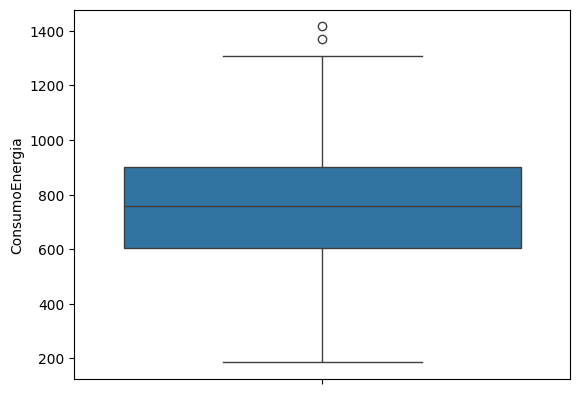

In [14]:
sns.boxplot(df_1['ConsumoEnergia'])

<Axes: xlabel='TamanhoResidencia', ylabel='ConsumoEnergia'>

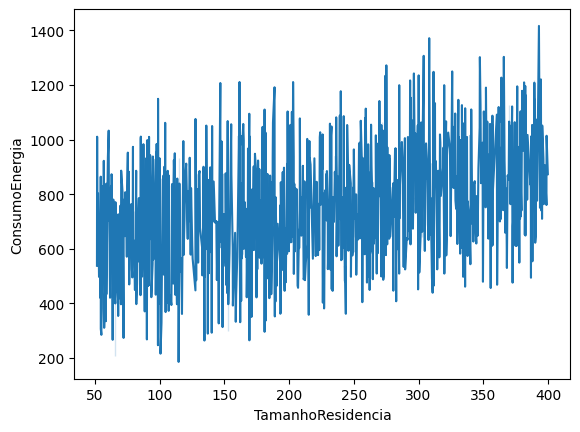

In [15]:
sns.lineplot(x='TamanhoResidencia', y='ConsumoEnergia', data=df_1)

<Axes: xlabel='NumeroMoradores', ylabel='ConsumoEnergia'>

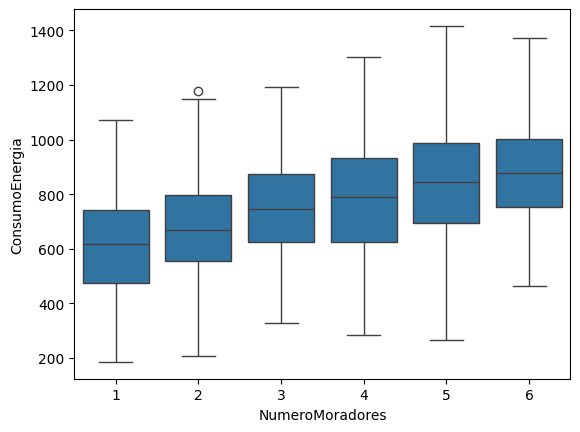

In [16]:
sns.boxplot(x='NumeroMoradores', y='ConsumoEnergia', data=df_1)

<Axes: xlabel='NumeroAparelhos', ylabel='ConsumoEnergia'>

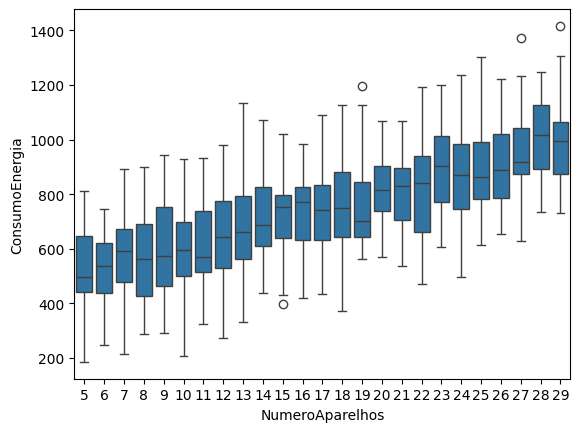

In [17]:
sns.boxplot(x='NumeroAparelhos', y='ConsumoEnergia', data=df_1)

<Axes: xlabel='UsoArCondicionado', ylabel='ConsumoEnergia'>

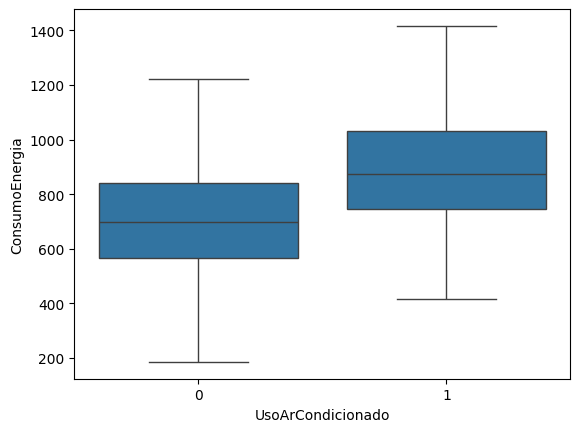

In [18]:
sns.boxplot(x='UsoArCondicionado', y='ConsumoEnergia', data=df_1)

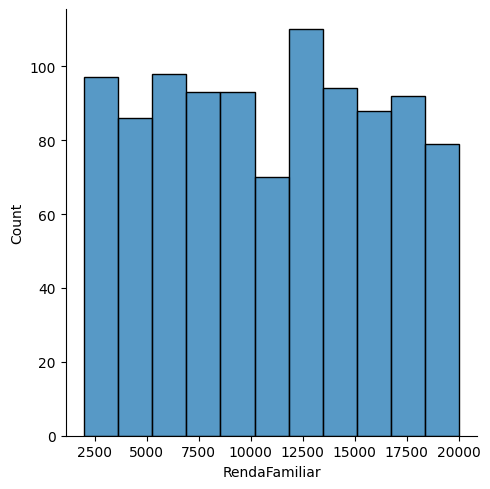

In [19]:
sns.displot(df_1['RendaFamiliar'])

## Feature Engineering

In [20]:
df_2 = df_1.copy()


In [21]:
# Renda por pessoa
df_2['RendaPerCapita'] = df_2['RendaFamiliar']/df_2['NumeroMoradores']

# Consumo Individual
df_2['ConsumoIndividual'] = df_2['ConsumoEnergia']/df_2['NumeroMoradores']

# Baixa renda
df_2['BaixaRenda'] = (df_2['RendaPerCapita'] < 1621).astype(int)

In [22]:
df_2['BaixaRenda'] = df_2['BaixaRenda'].astype(int)
df_2['UsoArCondicionado'] = df_2['UsoArCondicionado'].astype(int)
df_2.sample(5)

,IdResidencia,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia,RendaPerCapita,ConsumoIndividual,BaixaRenda
805,806,307.76,6,7,0,13948.84,631.70,2324.806667,105.283333,0
4,5,104.61,1,10,1,5962.00,558.26,5962.000000,558.260000,0
840,841,54.58,1,7,0,8169.16,305.42,8169.160000,305.420000,0
520,521,257.95,4,8,1,8314.74,761.99,2078.685000,190.497500,0
170,171,287.15,5,25,0,2344.61,991.17,468.922000,198.234000,1


### Filter Variables

```
Filtrar variáveis que são restrições de negócio
```

In [23]:
cols_drop = ['IdResidencia']
df_2 = df_2.drop(cols_drop, axis=1)

In [24]:
df_4 = df_2.copy()

### Univariate, Bivariate and Multivariate Data Analysis

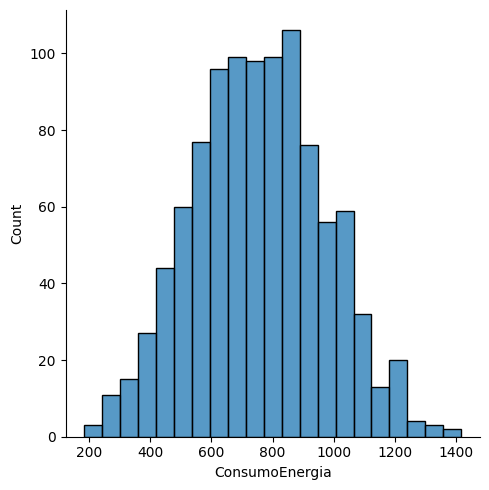

In [25]:
# Response Variable

sns.displot(df_4['ConsumoEnergia'])

In [26]:
num_attributes = df_4.select_dtypes(include=['int64', 'float64'])
cat_attributes = df_4.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

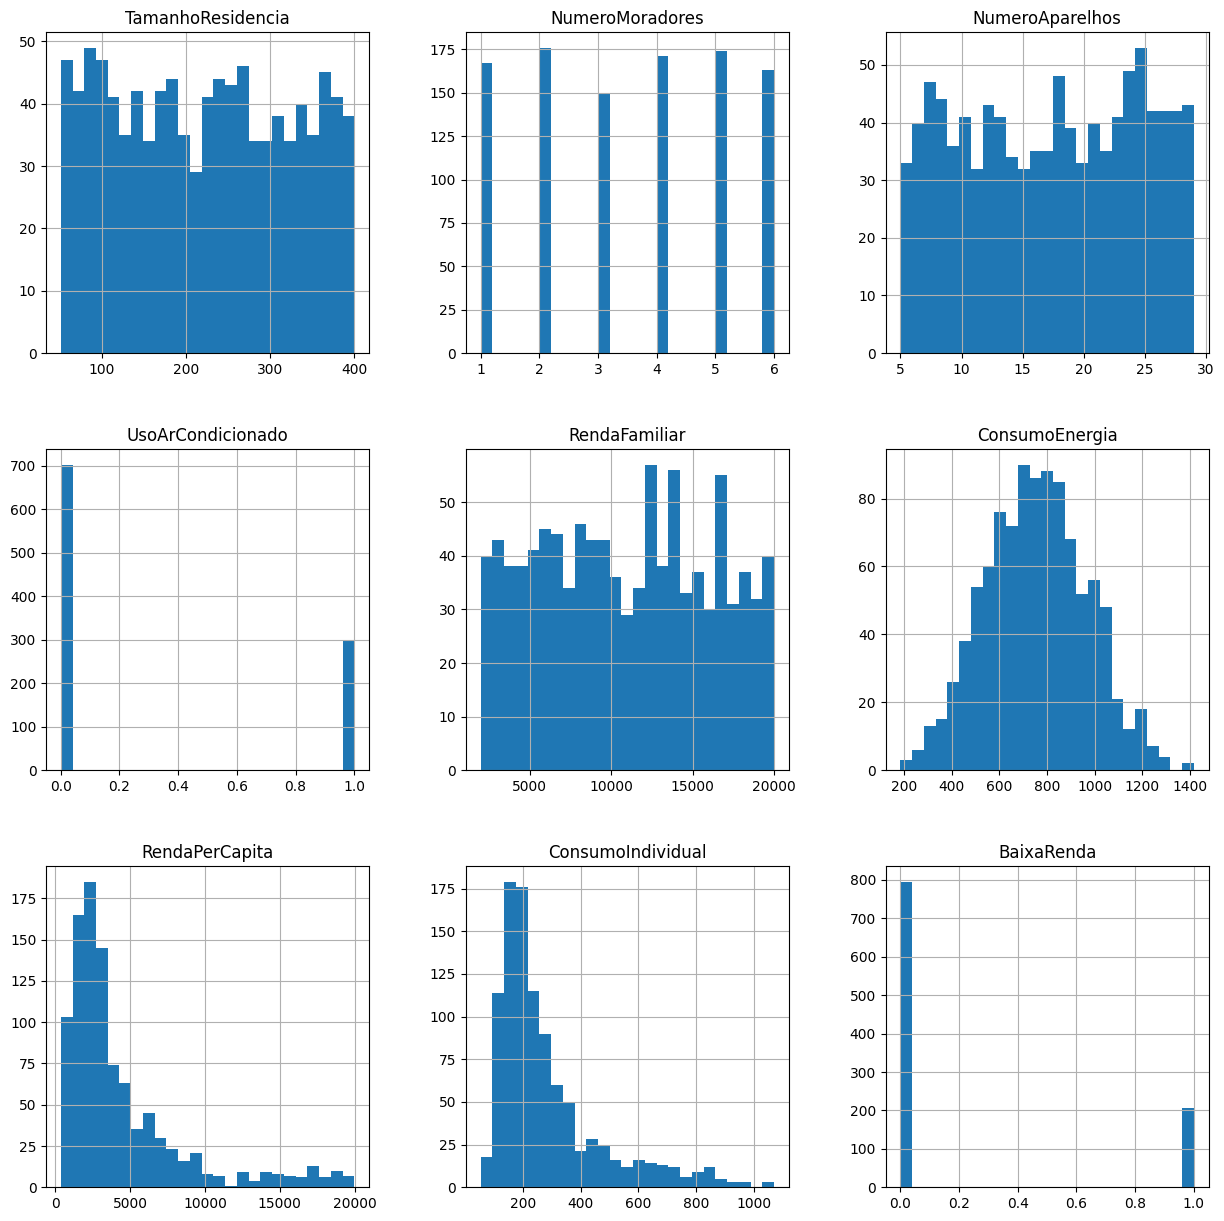

In [27]:
# Numerical Variables
num_attributes.hist(bins=25, figsize=(15, 15));

## Bivariate Analysis

<Axes: xlabel='NumeroMoradores', ylabel='ConsumoEnergia'>

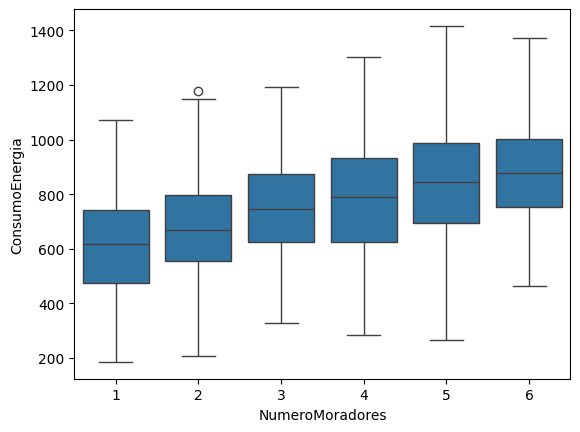

In [28]:
df_4

# Variaveis
# ConsumoEnergia X TamanhoResidencia
# ConsumoEnergia X NumeroMoradores
# ConsumoEnergia X NumeroAparelhos
# ConsumoEnergia X UsoArCondicionado
# ConsumoEnergia X RendaFamiliar
# ConsumoEnergia X RendaPerCapita
# ConsumoEnergia X ConsumoIndividual
# ConsumoEnergia X BaixaRenda

# ConsumoEnergia X TamanhoResidencia

sns.boxplot(x='NumeroMoradores', y='ConsumoEnergia', data=df_4)

<Axes: xlabel='NumeroAparelhos', ylabel='ConsumoEnergia'>

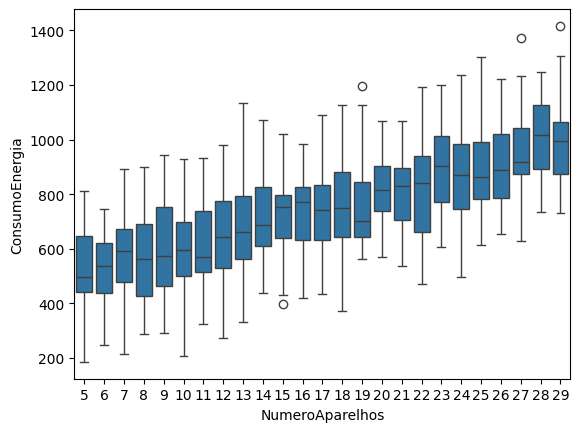

In [29]:
# ConsumoEnergia X NumeroAparelhos

sns.boxplot(x='NumeroAparelhos', y='ConsumoEnergia', data=df_4)

<Axes: xlabel='UsoArCondicionado', ylabel='ConsumoEnergia'>

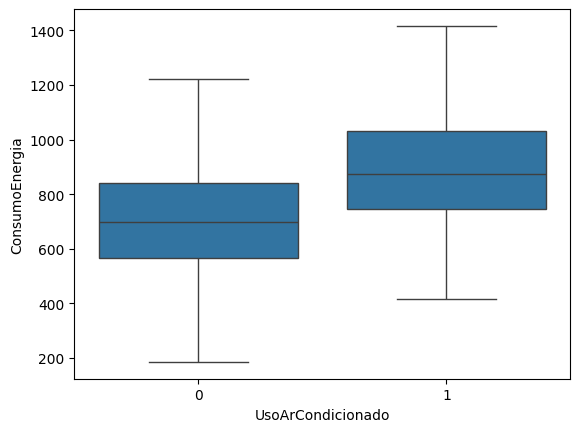

In [30]:
# ConsumoEnergia X ArCond

sns.boxplot(x='UsoArCondicionado', y='ConsumoEnergia', data=df_4)

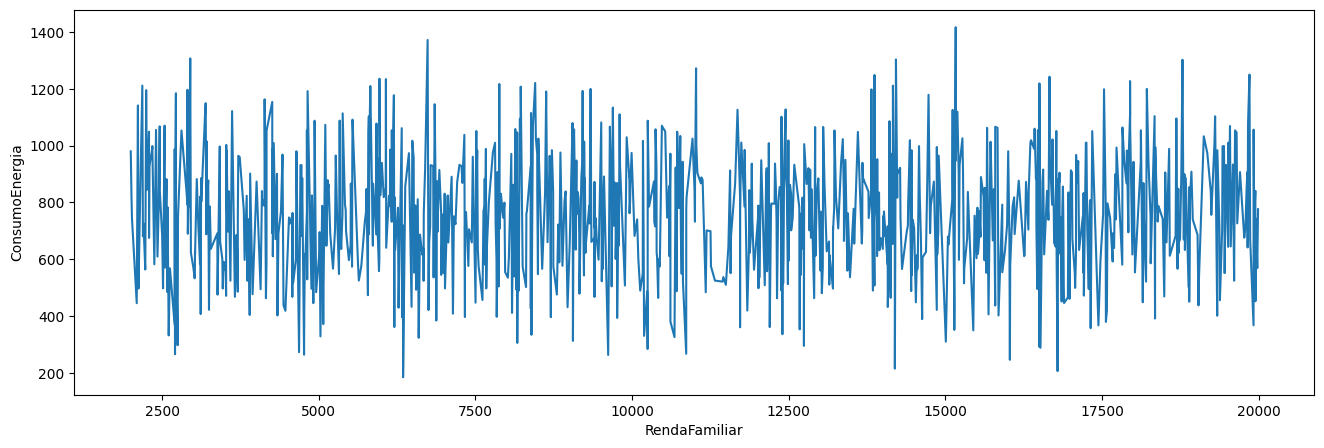

In [31]:
# ConsumoEnergia X RendaFamiliar

plt.figure(figsize=(16, 5))
sns.lineplot(x='RendaFamiliar', y='ConsumoEnergia', data=df_4)
plt.show()

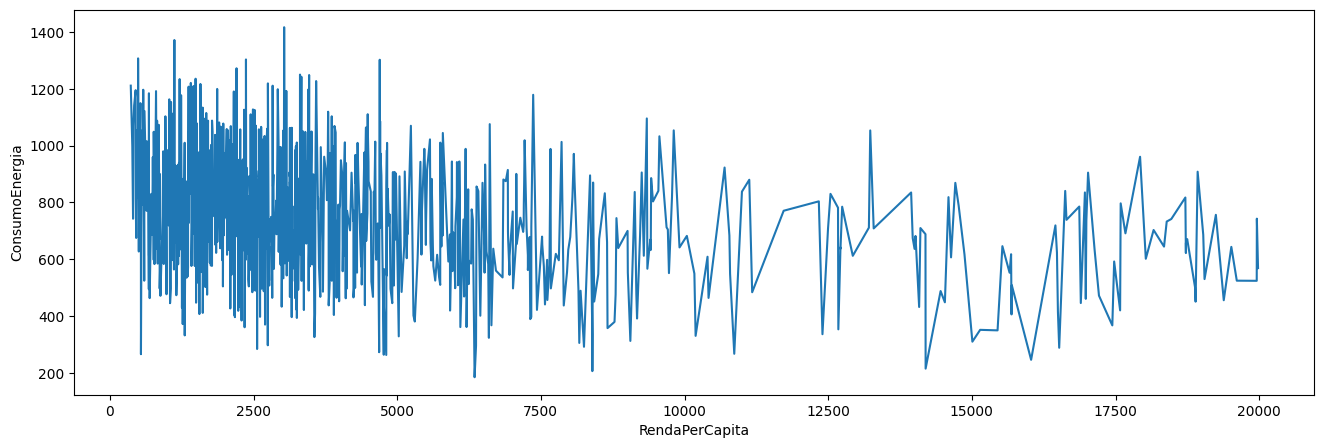

In [32]:
# ConsumoEnergia X RendaPerCapita

plt.figure(figsize=(16, 5))
sns.lineplot(x='RendaPerCapita', y='ConsumoEnergia', data=df_4)
plt.show()

<Axes: xlabel='BaixaRenda', ylabel='ConsumoEnergia'>

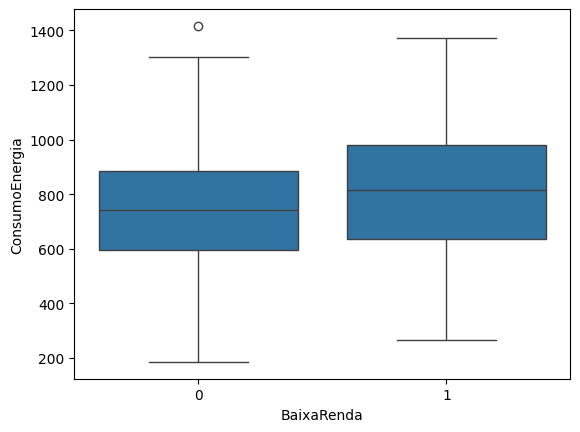

In [33]:
# ConsumoEnergia X BaixaRenda

sns.boxplot(x='BaixaRenda', y='ConsumoEnergia', data=df_4)

## Multivariate Anaysis

In [34]:
df_5 = df_4.copy()

In [35]:
cat_attributes = df_5.select_dtypes(exclude=['int64', 'float64'])
num_attributes = df_5.select_dtypes(include=['int64', 'float64'])

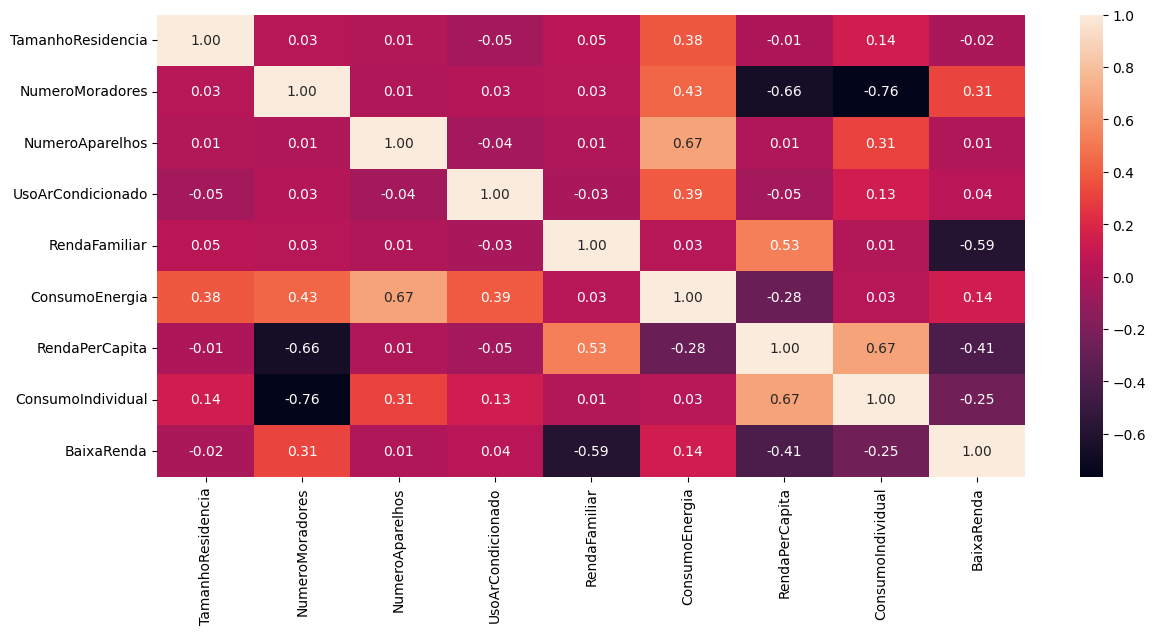

In [36]:
# Numerical Attributes

# Correlação
corr = num_attributes.corr(method='pearson')
plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, fmt=".2f") # fmt define as casas decimais do texto nas células
plt.show()

# Modelling

In [37]:
df_6 = df_5.copy()

In [38]:
df_6

,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia,RendaPerCapita,ConsumoIndividual,BaixaRenda
0,181.09,4,27,1,9802.50,1110.15,2450.625000,277.537500,0
1,382.75,6,8,0,19949.28,840.66,3324.880000,140.110000,0
2,306.20,3,22,0,12063.07,948.53,4021.023333,316.176667,0
3,259.53,5,27,0,7780.92,977.40,1556.184000,195.480000,1
4,104.61,1,10,1,5962.00,558.26,5962.000000,558.260000,0
...,...,...,...,...,...,...,...,...,...
995,82.05,1,12,0,7333.86,396.64,7333.860000,396.640000,0
996,371.06,3,15,0,4582.45,763.07,1527.483333,254.356667,1
997,97.89,3,24,0,4726.02,681.68,1575.340000,227.226667,1
998,382.58,4,5,0,9789.89,648.05,2447.472500,162.012500,0


## Data Preparation

In [39]:
# Seleciona apenas as colunas numéricas
num_cols = df_6.select_dtypes(include=np.number).columns

# Dicionário para armazenar resultados
normality_results = {}

for col in num_cols:
  data = df_6[col].dropna()
  stat, p = kstest(data, 'norm', args=(np.mean(data), np.std(data)))
  normality_results[col] = {'Statistic': stat, 'p-value': p, 'Normal?': p > 0.05}

# Converte em DataFrame para visualização
normality_df = pd.DataFrame(normality_results).T
print(normality_df)

                  Statistic   p-value Normal?
TamanhoResidencia  0.067611  0.000203   False
NumeroMoradores    0.152252       0.0   False
NumeroAparelhos    0.093898       0.0   False
UsoArCondicionado   0.44465       0.0   False
RendaFamiliar      0.062301  0.000812   False
ConsumoEnergia     0.019683  0.825758    True
RendaPerCapita     0.192063       0.0   False
ConsumoIndividual  0.170309       0.0   False
BaixaRenda         0.489203       0.0   False


In [40]:
# Selection the numerical variables
df_7 = df_6.copy()
num = df_7.select_dtypes(include=np.number)
num

,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia,RendaPerCapita,ConsumoIndividual,BaixaRenda
0,181.09,4,27,1,9802.50,1110.15,2450.625000,277.537500,0
1,382.75,6,8,0,19949.28,840.66,3324.880000,140.110000,0
2,306.20,3,22,0,12063.07,948.53,4021.023333,316.176667,0
3,259.53,5,27,0,7780.92,977.40,1556.184000,195.480000,1
4,104.61,1,10,1,5962.00,558.26,5962.000000,558.260000,0
...,...,...,...,...,...,...,...,...,...
995,82.05,1,12,0,7333.86,396.64,7333.860000,396.640000,0
996,371.06,3,15,0,4582.45,763.07,1527.483333,254.356667,1
997,97.89,3,24,0,4726.02,681.68,1575.340000,227.226667,1
998,382.58,4,5,0,9789.89,648.05,2447.472500,162.012500,0


<Axes: ylabel='ConsumoIndividual'>

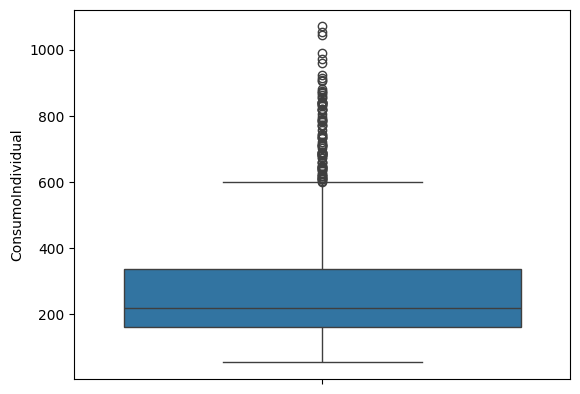

In [41]:
sns.boxplot(y='ConsumoIndividual', data=df_7)

In [42]:
# Rescaling
rs = RobustScaler() # sem outlier
mms= MinMaxScaler() # com outlier

# Robust Scaler
df_7['RendaPerCapita'] = rs.fit_transform(df_7[['RendaPerCapita']].values)
df_7['ConsumoIndividual'] = rs.fit_transform(df_7[['ConsumoIndividual']].values)

# MinMaxScaler
df_7['NumeroMoradores'] = mms.fit_transform(df_7[['NumeroMoradores']].values)
df_7['UsoArCondicionado'] = mms.fit_transform(df_7[['UsoArCondicionado']].values)
df_7['BaixaRenda'] = mms.fit_transform(df_7[['BaixaRenda']].values)
df_7['ConsumoEnergia'] = mms.fit_transform(df_7[['ConsumoEnergia']].values)
df_7['TamanhoResidencia'] = mms.fit_transform(df_7[['TamanhoResidencia']].values)
df_7['NumeroAparelhos'] = mms.fit_transform(df_7[['NumeroAparelhos']].values)
df_7['RendaFamiliar'] = mms.fit_transform(df_7[['RendaFamiliar']].values)

In [43]:
df_7

,TamanhoResidencia,NumeroMoradores,NumeroAparelhos,UsoArCondicionado,RendaFamiliar,ConsumoEnergia,RendaPerCapita,ConsumoIndividual,BaixaRenda
0,0.371741,0.6,0.916667,1.0,0.433647,0.751132,-0.159110,0.338815,0.0
1,0.950758,1.0,0.125000,0.0,0.997623,0.532401,0.081016,-0.442665,0.0
2,0.730964,0.4,0.708333,0.0,0.559293,0.619954,0.272222,0.558536,0.0
3,0.596962,0.8,0.916667,0.0,0.321284,0.643386,-0.404782,-0.127804,1.0
4,0.152148,0.0,0.208333,1.0,0.220185,0.303191,0.805340,1.935140,0.0
...,...,...,...,...,...,...,...,...,...
995,0.087372,0.0,0.291667,0.0,0.296435,0.172013,1.182142,1.016090,0.0
996,0.917193,0.4,0.416667,0.0,0.143507,0.469425,-0.412665,0.206998,1.0
997,0.132853,0.4,0.791667,0.0,0.151487,0.403365,-0.399520,0.052723,1.0
998,0.950270,0.6,0.000000,0.0,0.432946,0.376069,-0.159976,-0.318116,0.0


## Feature Selection

In [44]:
df_8 = df_7.copy()


In [45]:
# Seleção Univariada - Correlação

# Pearson Correlation
corr = df_8.corr()

# Filter features with high corr
to_drop = []
threshold = 0.90
for column in corr.columns:
  # Pegamos todas as correlações dessa coluna, exceto a própria (drop da diagonal = 1.0)
  high_corr = corr[column].drop(labels=[column])

  # Verifica se alguma correlação ultrapassa os limites
  if any((high_corr > threshold) | (high_corr < -threshold)):
    to_drop.append(column)

print("Colunas com alta correlação (> 0.90 ou < -0.90):", to_drop)

Colunas com alta correlação (> 0.90 ou < -0.90): []


             Feature  Importance
2    NumeroAparelhos    0.407576
1    NumeroMoradores    0.187099
0  TamanhoResidencia    0.147281
3  UsoArCondicionado    0.135317
6  ConsumoIndividual    0.087469
5     RendaPerCapita    0.023600
4      RendaFamiliar    0.010811
7         BaixaRenda    0.000847


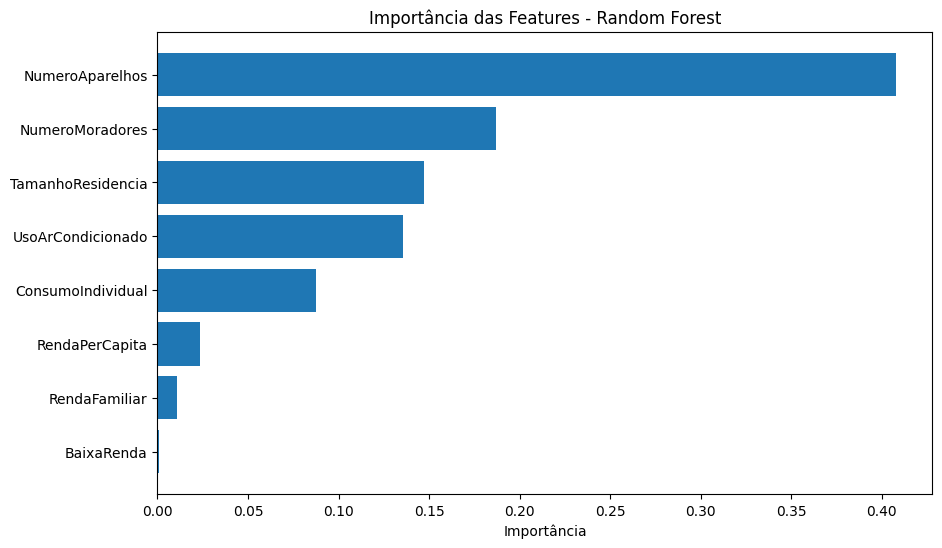

In [46]:
# Seleção por Importancia - Método Embutido

# Retirando o target
X = df_8.drop(columns=['ConsumoEnergia'])
y = df_8['ConsumoEnergia']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Random Forest
rf = RandomForestRegressor(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

# Importância das features
importances = rf.feature_importances_
feature_names = X.columns

# Organizar em DataFrame
feat_importances = pd.DataFrame({
  "Feature": feature_names,
  "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importances)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_importances["Feature"], feat_importances["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.title("Importância das Features - Random Forest")
plt.show()

In [47]:
# Filtra apenas colunas importantes + a coluna 'ConsunoEnergia'

cols_to_keep = feat_importances[feat_importances['Importance'] > 0.01]['Feature'].tolist()
df_8 = df_8[cols_to_keep + ['ConsumoEnergia']]
df_8.sample(2)


,NumeroAparelhos,NumeroMoradores,TamanhoResidencia,UsoArCondicionado,ConsumoIndividual,RendaPerCapita,RendaFamiliar,ConsumoEnergia
184,0.708333,0.0,0.254565,0.0,2.789250,2.600392,0.583436,0.425101
705,0.208333,0.8,0.990209,1.0,-0.183702,-0.457176,0.268271,0.603493


## Machine Learning Algorithms

In [48]:
df_9 = df_8.copy()

In [49]:
# Retirando o target
X = df_9.drop(columns=['ConsumoEnergia'])
y = df_9['ConsumoEnergia']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reverte o log para os valores reais
y_train_real = np.expm1(y_train)
y_test_real = np.expm1(y_test)

In [50]:
df_9

,NumeroAparelhos,NumeroMoradores,TamanhoResidencia,UsoArCondicionado,ConsumoIndividual,RendaPerCapita,RendaFamiliar,ConsumoEnergia
0,0.916667,0.6,0.371741,1.0,0.338815,-0.159110,0.433647,0.751132
1,0.125000,1.0,0.950758,0.0,-0.442665,0.081016,0.997623,0.532401
2,0.708333,0.4,0.730964,0.0,0.558536,0.272222,0.559293,0.619954
3,0.916667,0.8,0.596962,0.0,-0.127804,-0.404782,0.321284,0.643386
4,0.208333,0.0,0.152148,1.0,1.935140,0.805340,0.220185,0.303191
...,...,...,...,...,...,...,...,...
995,0.291667,0.0,0.087372,0.0,1.016090,1.182142,0.296435,0.172013
996,0.416667,0.4,0.917193,0.0,0.206998,-0.412665,0.143507,0.469425
997,0.791667,0.4,0.132853,0.0,0.052723,-0.399520,0.151487,0.403365
998,0.000000,0.6,0.950270,0.0,-0.318116,-0.159976,0.432946,0.376069


In [51]:
# Average Model
# Modelo simples: média das vendas reais do treino
y_pred = np.full(shape=len(y_test_real), fill_value=y_train_real.mean())
# Metrics
mae_average = round(mean_absolute_error(y_test_real, y_pred),2)
mape_average = round(np.mean(np.abs((y_test_real - y_pred) / y_test_real)),2)
rmse_average = round(np.sqrt(mean_squared_error(y_test_real, y_pred)),2)

print("Média de treino usada como predição:", round(y_train_real.mean()))
print("MAE:", mae_average)
print("MAPE:", mape_average)
print("RMSE:", rmse_average)


Média de treino usada como predição: 1
MAE: 0.23
MAPE: 0.58
RMSE: 0.29


In [52]:
# Linear Regression
# Model
lr = LinearRegression().fit( X_train, y_train )
# Prediction
y_pred_lr_log = lr.predict( X_test )
# Reverte para escala real
y_pred_lr = np.expm1(y_pred_lr_log)
# Metrics
mae_lr = round(mean_absolute_error(y_test_real, y_pred_lr),2)
mape_lr = round(np.mean(np.abs((y_test_real - y_pred_lr) / y_test_real)),2)
rmse_lr = round(np.sqrt(mean_squared_error(y_test_real, y_pred_lr)),2)
print("Linear Regression:")
print("MAE:", mae_lr)
print("MAPE:", mape_lr)
print("RMSE:", rmse_lr)

Linear Regression:
MAE: 0.05
MAPE: 0.1
RMSE: 0.07


In [53]:
# Elastic Net Regression
# Model
el = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,     # 0 = Ridge | 1 = Lasso
    random_state=42,
    max_iter=5000
)

el.fit(X_train, y_train)

# Prediction
y_pred_en = el.predict(X_test)

# Metrics
mae_el = round(mean_absolute_error(y_test, y_pred_en), 2)
mape_el = round(np.mean(np.abs((y_test - y_pred_en) / y_test)), 2)
rmse_el = round(np.sqrt(mean_squared_error(y_test, y_pred_en)), 2)

print("Elastic Net:")
print("MAE:", mae_el)
print("MAPE:", mape_el)
print("RMSE:", rmse_el)


Elastic Net:
MAE: 0.14
MAPE: 0.44
RMSE: 0.17


In [54]:
# Linear Regression Regularized - Lasso
# Model
lrr = Lasso( alpha=0.01 ).fit( X_train, y_train )

# Prediction
y_pred_lrr_log = lrr.predict( X_test )

# Reverte para escala real
y_pred_lrr = np.expm1(y_pred_lrr_log)

# Metrics
mae_lasso = round(mean_absolute_error(y_test_real, y_pred_lrr),2)
mape_lasso = round(np.mean(np.abs((y_test_real - y_pred_lrr) / y_test_real)),2)
rmse_lasso = round(np.sqrt(mean_squared_error(y_test_real, y_pred_lrr)),2)

print("Lasso:")
print("MAE:", mae_lasso)
print("MAPE:", mape_lasso)
print("RMSE:", rmse_lasso)

Lasso:
MAE: 0.09
MAPE: 0.21
RMSE: 0.12


In [55]:
# Random Forest

# Model
rf = RandomForestRegressor( n_estimators=100, max_depth=5, n_jobs=-1, random_state=42 ).fit( X_train, y_train )

# Prediction
y_pred_rf_log = rf.predict( X_test )

# Reverte para escala real
y_pred_rf = np.expm1(y_pred_rf_log)

# Metrics
mae_rf = round(mean_absolute_error(y_test_real, y_pred_rf),2)
mape_rf = round(np.mean(np.abs((y_test_real - y_pred_rf) / y_test_real)),2)
rmse_rf = round(np.sqrt(mean_squared_error(y_test_real, y_pred_rf)),2)

print("Random Forest:")
print("MAE:", mae_rf)
print("MAPE:", mape_rf)
print("RMSE:", rmse_rf)

Random Forest:
MAE: 0.07
MAPE: 0.14
RMSE: 0.09


In [56]:
# XGBoost Regressor

# Model
model_xgb = xgb.XGBRegressor( objective='reg:squarederror',
                              n_estimators=1000, # num árvores
                              learning_rate=0.05, # taxa de aprendizado
                              max_depth=5, # profudidade das árvores
                              subsample=0.8, # amostragem
                              colsample_bytree=0.8, # seleciona colunas aleatórias
                              random_state=42).fit( X_train, y_train )

# Prediction
y_pred_xgb_log = model_xgb.predict( X_test )

# Reverte para escala real
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Metrics
mae_xgb = round(mean_absolute_error(y_test_real, y_pred_xgb),2)
mape_xgb = round(np.mean(np.abs((y_test_real - y_pred_xgb) / y_test_real)),2)
rmse_xgb = round(np.sqrt(mean_squared_error(y_test_real, y_pred_xgb)),2)

print("XGBoost:")
print("MAE:", mae_xgb)
print("MAPE:", mape_xgb)
print("RMSE:", rmse_xgb)


XGBoost:
MAE: 0.04
MAPE: 0.07
RMSE: 0.05


In [57]:
# Compare Models
models = pd.DataFrame({
      'Model': ['Average','Linear Regression', 'Elastic Net', 'Lasso', 'Random Forest', 'XGBoost'],
      'MAE': [mae_average, mae_lr, mae_el,mae_lasso, mae_rf, mae_xgb],
      'MAPE': [mape_average, mape_lr, mape_el,mape_lasso, mape_rf, mape_xgb],
      'RMSE': [rmse_average, rmse_lr, rmse_el,rmse_lasso, rmse_rf, rmse_xgb]
      })
# Sort by RMSE and overwrite the DataFrame
models = models.sort_values(by='MAPE', ascending=True)
# Display the sorted DataFrame
models

,Model,MAE,MAPE,RMSE
5,XGBoost,0.04,0.07,0.05
1,Linear Regression,0.05,0.10,0.07
4,Random Forest,0.07,0.14,0.09
3,Lasso,0.09,0.21,0.12
2,Elastic Net,0.14,0.44,0.17
0,Average,0.23,0.58,0.29


## Cross Validation

In [58]:
from sklearn.model_selection import TimeSeriesSplit, StratifiedShuffleSplit, ShuffleSplit

# Linear Regressor
# Configura o modelo
lr = LinearRegression()

# Configura o cross validation
tscv = ShuffleSplit(n_splits=5)
mae_scores, mape_scores, rmse_scores = [], [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X_train)):
  # Divide os dados
  X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
  y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]

  # Treina o modelo
  lr.fit(X_train_cv, y_train_cv)

  # Predição (em escala log)
  y_pred_log = lr.predict(X_test_cv)

  # Reverte para escala real
  y_pred = np.expm1(y_pred_log)
  y_test_real_cv = np.expm1(y_test_cv)

  # Métricas
  mae = mean_absolute_error(y_test_real_cv, y_pred)
  # mape = np.mean(np.abs((y_test_real_cv - y_pred) / y_test_real_cv))
  mape = np.mean(
      2 * np.abs(y_pred - y_test_real_cv) /
      (np.abs(y_test_real_cv) + np.abs(y_pred))
  )
  rmse = np.sqrt(mean_squared_error(y_test_real_cv, y_pred))
  mae_scores.append(mae)
  mape_scores.append(mape)
  rmse_scores.append(rmse)

  print(f"Fold {fold}: MAE={mae:.2f}, MAPE={mape:.2f}, RMSE={rmse:.2f}")

# Resultado final com média e desvio padrão
mae_lr = f"{np.mean(mae_scores):.2f} +/- {np.std(mae_scores):.2f}"
mape_lr = f"{np.mean(mape_scores):.2f} +/- {np.std(mape_scores):.2f}"
rmse_lr = f"{np.mean(rmse_scores):.2f} +/- {np.std(rmse_scores):.2f}"
print("\nMédia dos folds (+/- desvio padrão):")
print("MAE: ", mae_lr)
print("MAPE:", mape_lr)
print("RMSE:", rmse_lr)

Fold 0: MAE=0.05, MAPE=0.12, RMSE=0.06
Fold 1: MAE=0.06, MAPE=0.12, RMSE=0.07
Fold 2: MAE=0.06, MAPE=0.10, RMSE=0.07
Fold 3: MAE=0.05, MAPE=0.12, RMSE=0.06
Fold 4: MAE=0.05, MAPE=0.11, RMSE=0.07

Média dos folds (+/- desvio padrão):
MAE:  0.05 +/- 0.00
MAPE: 0.11 +/- 0.01
RMSE: 0.07 +/- 0.01


In [59]:
import xgboost as xgb

def smape(y_true, y_pred):
    return np.mean( 2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Configura o cross validation
tscv = ShuffleSplit(n_splits=5)

mae_lr, smape_lr, rmse_lr = [], [], []
mae_rf, smape_rf, rmse_rf = [], [], []
mae_xgb, smape_xgb, rmse_xgb = [], [], []
mae_el, smape_el, rmse_el = [], [], []

for fold, (train_index, test_index) in enumerate(tscv.split(X_train)):
    # Divide os dados
    X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
    y_train_cv, y_test_cv = y_train.iloc[train_index], y_train.iloc[test_index]

    # =====================
    # Regressão Linear
    # =====================
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    pred_lr = np.expm1(pred_lr)

    mae_lr.append(mean_absolute_error(y_test, pred_lr))
    smape_lr.append(smape(y_test, pred_lr))
    rmse_lr.append(np.sqrt(mean_squared_error(y_test, pred_lr)))

    # =====================
    # Elastic Net Regression
    # =====================
    el = ElasticNet(
      alpha=0.1,
      l1_ratio=0.5,     # 0 = Ridge | 1 = Lasso
      random_state=42,
      max_iter=500
    )

    el.fit(X_train, y_train)
    pred_el = el.predict(X_test)

    mae_el.append(mean_absolute_error(y_test, pred_el))
    smape_el.append(smape(y_test, pred_el))
    rmse_el.append(np.sqrt(mean_squared_error(y_test, pred_el)))

    # =====================
    # Random Forest
    # =====================
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    mae_rf.append(mean_absolute_error(y_test, pred_rf))
    smape_rf.append(smape(y_test, pred_rf))
    rmse_rf.append(np.sqrt(mean_squared_error(y_test, pred_rf)))

    # =====================
    # XGBoost
    # =====================
    model_xgb = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
    model_xgb.fit(X_train, y_train)
    pred_xgb = model_xgb.predict(X_test)

    mae_xgb.append(mean_absolute_error(y_test, pred_xgb))
    smape_xgb.append(smape(y_test, pred_xgb))
    rmse_xgb.append(np.sqrt(mean_squared_error(y_test, pred_xgb)))

print('____________________________________')
print('')
print('MÉDIAS FINAIS (5 folds)')
print('____________________________________')
print('')
print('Regressão Linear')
print('MAE:', round(np.mean(mae_lr), 4))
print('SMAPE:', round(np.mean(smape_lr), 4))
print('RMSE:', round(np.mean(rmse_lr), 4))

print('')
print('Elastic Net')
print('MAE:', round(np.mean(mae_el), 4))
print('SMAPE:', round(np.mean(smape_el), 4))
print('RMSE:', round(np.mean(rmse_el), 4))

print('')
print('Random Forest')
print('MAE:', round(np.mean(mae_rf), 4))
print('SMAPE:', round(np.mean(smape_rf), 4))
print('RMSE:', round(np.mean(rmse_rf), 4))

print('')
print('XGBoost')
print('MAE:', round(np.mean(mae_xgb), 4))
print('SMAPE:', round(np.mean(smape_xgb), 4))
print('RMSE:', round(np.mean(rmse_xgb), 4))



____________________________________

MÉDIAS FINAIS (5 folds)
____________________________________

Regressão Linear
MAE: 0.1449
SMAPE: 0.2492
RMSE: 0.1823

Elastic Net
MAE: 0.1422
SMAPE: 0.3287
RMSE: 0.1731

Random Forest
MAE: 0.0295
SMAPE: 0.0738
RMSE: 0.0385

XGBoost
MAE: 0.026
SMAPE: 0.0664
RMSE: 0.0349


## Fine Tunning

In [60]:
# Elastic Net

# Modelo base
el_model = ElasticNet(random_state=42)

# Espaço de busca
param_dist = {
    'alpha': [0.1, 0.5, 1],
    'l1_ratio': [0, 0.5, 1],
    'max_iter':[50, 70, 100, 300]
}

# K-Fold
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=el_model,
    param_grid=param_dist,
    cv=k_folds,
    scoring='neg_root_mean_squared_log_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_search.best_params_)

best_el = grid_search.best_estimator_

scores = cross_val_score(
    best_el,
    X_train,
    y_train,
    cv=k_folds,
    scoring='neg_root_mean_squared_log_error',
    n_jobs=-1
)

print("Resultado neg_root_mean_squared_log_error:", round(100 - (-grid_search.best_score_), 2), -scores)

Melhores parâmetros:
{'alpha': 0.1, 'l1_ratio': 0, 'max_iter': 50}
Resultado neg_root_mean_squared_log_error: 99.94 [0.0594568  0.05850715 0.05650992 0.06949733 0.05974195]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.542e+00, tolerance: 2.401e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


In [61]:
# BayesSearch
import xgboost as xgb

# Define the parameter distribution
param_dist = {
  'n_estimators': [10, 100, 500, 1000],
  'max_depth': [4, 6, 7],
  'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.9],
  'reg_alpha': [0, 0.1, 0.5, 1.0],
  'reg_lambda': [0, 0.1, 0.5, 1.0],
  'scale_pos_weight': [1, 2, 5, 10],
  'colsample_bytree': [0.5, 0.75, 1.0],
  'subsample': [0.5, 0.75, 1.0],
  'gamma': [0, 0.1, 0.5, 1.0],

}

# Configura o modelo
xgb_model = xgb.XGBRegressor(objective='reg:squarederror')

# K-Fold
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# Bayes Search
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_dist,
    n_iter=50,
    cv=k_folds,
    n_jobs=-1,
    verbose=0,
    random_state=42
)

bayes_search.fit(X_train, y_train)

# Model configuration
xgb = xgb.XGBRegressor(objective='reg:squarederror', **bayes_search.best_params_)

# Prediction
y_pred_xgb_log = model_xgb.predict( X_test )

# Reverte para escala real
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Metrics
mae_xgb = round(mean_absolute_error(y_test_real, y_pred_xgb),2)
mape_xgb = round(np.mean(np.abs((y_test_real - y_pred_xgb) / y_test_real)),2)
rmse_xgb = round(np.sqrt(mean_squared_error(y_test_real, y_pred_xgb)),2)

print("XGBoost:")
print("MAE:", mae_xgb)
print("MAPE:", mape_xgb)
print("RMSE:", rmse_xgb)

XGBoost:
MAE: 0.04
MAPE: 0.08
RMSE: 0.06


# 5. Avaliação do Modelo

```
A partir das seções acima foi possível visualizar que o Elastic Net demonstrou um otimo resultado
```